In [1]:
# Cell 1: Setup and Advanced Analysis Imports
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from scipy.stats import chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.discrete.discrete_model import Logit
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Add src to path
sys.path.insert(0, str(Path('..').resolve()))

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR, TABLES_DIR

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete")
print(f"Lifelines version: {lifelines.__version__}")

Setup complete
Lifelines version: 0.30.3


In [2]:
# Cell 2: Load Cleaned Data
modeling_df = pd.read_csv(PROCESSED_DATA_DIR / "ethiopia_early_marriage_modeling_ready_fixed.csv")

# Create analysis dataset (ever-married women aged 20-49)
dhs_analysis = modeling_df[
    (modeling_df['ever_married'] == 1) &
    (modeling_df['current_age'] >= 20) &
    (modeling_df['current_age'] <= 49) &
    (modeling_df['age_first_marriage'].notna())
].copy()

print(f"Analysis dataset shape: {len(dhs_analysis):,} rows")
print(f"Columns: {dhs_analysis.columns.tolist()}")

Analysis dataset shape: 41,247 rows
Columns: ['survey_year', 'sample_weight', 'age_first_marriage', 'early_marriage', 'ever_married', 'marital_status', 'current_age', 'education_level', 'education_level_num', 'education_years', 'literate', 'children_ever_born', 'children_surviving', 'children_deceased', 'ideal_children', 'currently_working', 'residence', 'residence_urban', 'region', 'region_code', 'religion', 'ethnicity', 'has_electricity', 'water_improved', 'toilet_improved', 'floor_finished', 'asset_count', 'wealth_proxy_score', 'wealth_quintile', 'wealth_quintile_num']


In [3]:
# Cell 3: Prepare Data - Create Numeric Versions of Categorical Variables
# Convert categorical variables to numeric for advanced models

dhs_analysis['wealth_numeric'] = dhs_analysis['wealth_quintile'].map({
    'Poorest': 1, 'Poorer': 2, 'Middle': 3, 'Richer': 4, 'Richest': 5
})

dhs_analysis['residence_binary'] = (dhs_analysis['residence'] == 'urban').astype(int)

dhs_analysis['primary_education'] = (dhs_analysis['education_level'] == 'primary').astype(int)
dhs_analysis['secondary_plus_education'] = (dhs_analysis['education_level'].isin(['secondary', 'higher'])).astype(int)

# Create cluster variable (using region as proxy if no cluster ID)
if 'cluster' in dhs_analysis.columns:
    dhs_analysis['cluster_id'] = dhs_analysis['cluster']
else:
    # Use household ID as cluster proxy
    dhs_analysis['cluster_id'] = dhs_analysis.get('household', range(len(dhs_analysis)))

print("Data preparation complete")
print(f"Wealth numeric - min: {dhs_analysis['wealth_numeric'].min()}, max: {dhs_analysis['wealth_numeric'].max()}")
print(f"Residence binary - urban %: {dhs_analysis['residence_binary'].mean()*100:.1f}%")

Data preparation complete
Wealth numeric - min: 1, max: 5
Residence binary - urban %: 26.0%


In [4]:
# Cell 4: Multilevel Logistic Regression - Account for Clustering
print("="*60)
print("1. MULTILEVEL LOGISTIC REGRESSION (Mixed Effects)")
print("="*60)

import statsmodels.formula.api as smf

# Prepare data for mixed effects model
mixed_df = dhs_analysis[['early_marriage', 'current_age', 'education_level', 'residence', 
                         'wealth_quintile', 'survey_year', 'cluster_id']].dropna()

# Convert to appropriate types
mixed_df['early_marriage'] = mixed_df['early_marriage'].astype(float)
mixed_df['current_age'] = mixed_df['current_age'].astype(float)

# Try to fit mixed effects model (may take a moment)
try:
    # Mixed effects logistic regression with random intercept for cluster
    mixed_model = smf.mixedlm(
        "early_marriage ~ C(education_level) + C(residence) + C(wealth_quintile) + current_age + C(survey_year)",
        mixed_df,
        groups=mixed_df["cluster_id"],
        re_formula="~1"
    )
    
    mixed_result = mixed_model.fit(method='lbfgs', maxiter=1000)
    print(mixed_result.summary())
    
    # Calculate ICC (Intraclass Correlation Coefficient)
    # For logistic mixed models, ICC = var_random / (var_random + π²/3)
    var_random = mixed_result.cov_re.iloc[0, 0]
    var_individual = np.pi**2 / 3
    icc = var_random / (var_random + var_individual)
    print(f"\nIntraclass Correlation Coefficient (ICC): {icc:.4f}")
    print(f"Interpretation: {icc*100:.1f}% of variance explained by cluster-level factors")
    
except Exception as e:
    print(f"Mixed model failed: {e}")
    print("Using region fixed effects as alternative")
    
    # Alternative: Region fixed effects
    region_fe_df = mixed_df.copy()
    region_dummies = pd.get_dummies(region_fe_df['cluster_id'].astype(str), prefix='cluster', drop_first=True)
    X = pd.concat([region_fe_df[['current_age']], region_dummies], axis=1)
    X = sm.add_constant(X)
    y = region_fe_df['early_marriage']
    
    model_fe = sm.Logit(y, X.astype(float)).fit(disp=0)
    print(f"Fixed effects model pseudo R-squared: {model_fe.prsquared:.4f}")

1. MULTILEVEL LOGISTIC REGRESSION (Mixed Effects)
                    Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      early_marriage
No. Observations:        41247        Method:                  REML          
No. Groups:              41247        Scale:                   0.1080        
Min. group size:         1            Log-Likelihood:          -26972.7441   
Max. group size:         1            Converged:               Yes           
Mean group size:         1.0                                                 
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.305    0.020 15.024 0.000  0.265  0.345
C(education_level)[T.no_education]  0.409    0.014 28.421 0.000  0.380  0.437
C(education_level)[T.primary]     

2. SURVIVAL ANALYSIS: AGE AT FIRST MARRIAGE
Survival dataset: 41,247 women
Events (married before 18): 26,259
Censored: 14,988


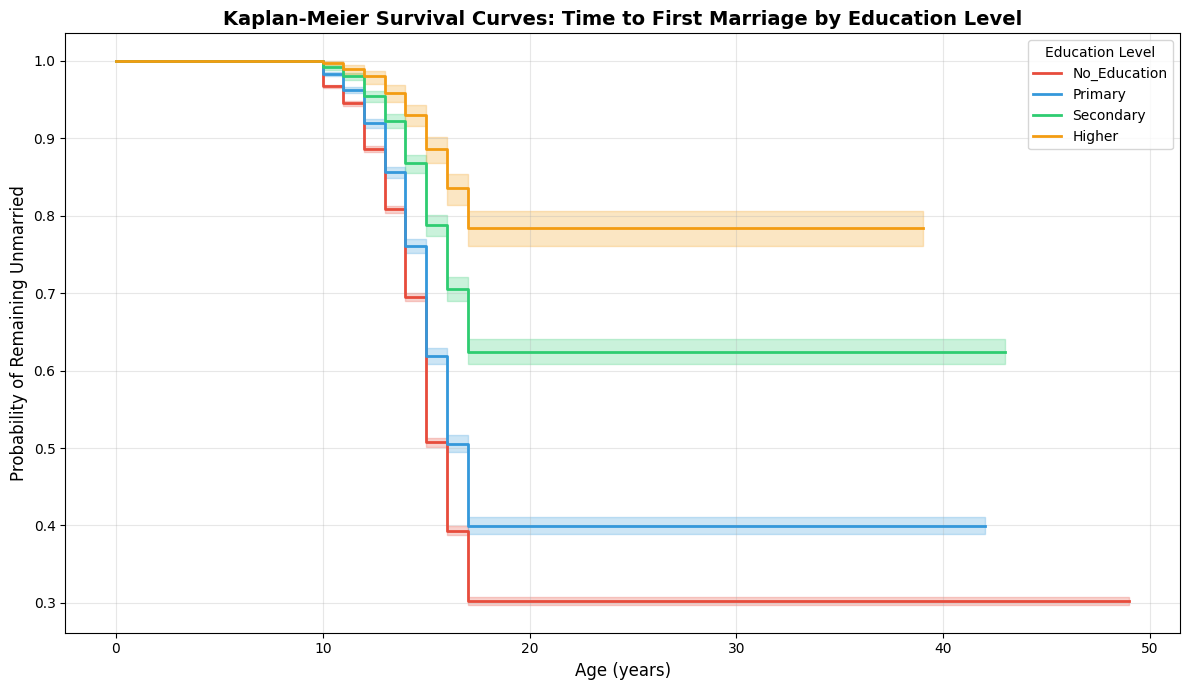


Log-rank test p-values (comparing survival curves):
  no_education vs primary: p=0.0000
  no_education vs secondary: p=0.0000
  no_education vs higher: p=0.0000
  primary vs secondary: p=0.0000
  primary vs higher: p=0.0000
  secondary vs higher: p=0.0000

Cox Proportional Hazards Model:


<lifelines.CoxPHFitter: fitted with 41247 total observations, 14988 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 41247
number of events observed = 26259
   partial log-likelihood = -266618.53
         time fit was run = 2026-04-07 03:06:53 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
current_age                   0.01      1.01      0.00            0.00            0.01                1.00                1.01
education_level_no_education  1.46      4.31      0.06            1.34            1.58                3.82                4.87
education_level_primary       1.23      3.44      0.06            1.11            1.36                3.04                3.88
education_level_secondary     0.64      1.91      0.07            0.52            0.77                1.68                2.17
residence_urban              -0.04      0.96      0.03           -0.09            0.01                0.91                1.01
wealth_quintile_Poorer       -0.05      0.95      0.03           -0.11            0.01                0.89                1.01
wealth_quintile_Poorest      -0.04      0.96      0.03           -0.10            0.02                0.90                1.02
wealth_quintile_Richer       -0.09      0.92      0.04           -0.16           -0.02                0.85                0.98
wealth_quintile_Richest      -0.21      0.81      0.03           -0.28           -0.14                0.75                0.87

                              cmp to     z      p  -log2(p)
covariate                                                  
current_age                     0.00  7.21 <0.005     40.73
education_level_no_education    0.00 23.62 <0.005    407.20
education_level_primary         0.00 19.92 <0.005    290.94
education_level_secondary       0.00  9.83 <0.005     73.28
residence_urban                 0.00 -1.56   0.12      3.07
wealth_quintile_Poorer          0.00 -1.59   0.11      3.16
wealth_quintile_Poorest         0.00 -1.43   0.15      2.72
wealth_quintile_Richer          0.00 -2.41   0.02      5.97
wealth_quintile_Richest         0.00 -6.08 <0.005     29.64
---
Concordance = 0.58
Partial AIC = 533255.05
log-likelihood ratio test = 2717.83 on 9 df
-log2(p) of ll-ratio test = inf


Cox results saved to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables\cox_hazard_ratios.csv


In [5]:
# Cell 5: Survival Analysis - Time to Marriage
print("="*60)
print("2. SURVIVAL ANALYSIS: AGE AT FIRST MARRIAGE")
print("="*60)

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Prepare survival data
surv_data = dhs_analysis.copy()
surv_data['event'] = surv_data['early_marriage'].astype(int)  # 1 = event occurred (married before 18)
surv_data['time'] = surv_data['age_first_marriage'].fillna(surv_data['current_age'])

# For never-married women, they are censored at current age
censored_mask = surv_data['ever_married'] == 0
surv_data.loc[censored_mask, 'event'] = 0
surv_data.loc[censored_mask, 'time'] = surv_data.loc[censored_mask, 'current_age']

# Remove missing
surv_data = surv_data.dropna(subset=['time', 'event'])
print(f"Survival dataset: {len(surv_data):,} women")
print(f"Events (married before 18): {surv_data['event'].sum():,}")
print(f"Censored: {(surv_data['event']==0).sum():,}")

# Kaplan-Meier by Education Level
fig, ax = plt.subplots(figsize=(12, 7))

kmf = KaplanMeierFitter()
colors = {'no_education': '#E74C3C', 'primary': '#3498DB', 'secondary': '#2ECC71', 'higher': '#F39C12'}

for edu in ['no_education', 'primary', 'secondary', 'higher']:
    subset = surv_data[surv_data['education_level'] == edu]
    if len(subset) > 0:
        kmf.fit(subset['time'], subset['event'], label=edu.title())
        kmf.plot(ax=ax, color=colors.get(edu, 'gray'), linewidth=2)

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Probability of Remaining Unmarried', fontsize=12)
ax.set_title('Kaplan-Meier Survival Curves: Time to First Marriage by Education Level', 
             fontsize=14, fontweight='bold')
ax.legend(title='Education Level')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kaplan_meier_education.png', dpi=300, bbox_inches='tight')
plt.show()

# Log-rank test
results = {}
for edu in ['no_education', 'primary', 'secondary', 'higher']:
    subset = surv_data[surv_data['education_level'] == edu]
    results[edu] = (subset['time'], subset['event'])

# Pairwise log-rank tests
print("\nLog-rank test p-values (comparing survival curves):")
edu_list = ['no_education', 'primary', 'secondary', 'higher']
for i, edu1 in enumerate(edu_list):
    for edu2 in edu_list[i+1:]:
        t1, e1 = results[edu1]
        t2, e2 = results[edu2]
        result = logrank_test(t1, t2, event_observed_A=e1, event_observed_B=e2)
        print(f"  {edu1} vs {edu2}: p={result.p_value:.4f}")

# Cox Proportional Hazards Model
print("\nCox Proportional Hazards Model:")
cox_data = surv_data[['time', 'event', 'education_level', 'residence', 'wealth_quintile', 'current_age']].dropna()
cox_data = pd.get_dummies(cox_data, columns=['education_level', 'residence', 'wealth_quintile'], drop_first=True)

cph = CoxPHFitter()
cph.fit(cox_data, duration_col='time', event_col='event')

cph.print_summary()

# Save results
cox_summary = cph.summary
cox_summary.to_csv(TABLES_DIR / 'cox_hazard_ratios.csv')
print(f"\nCox results saved to {TABLES_DIR / 'cox_hazard_ratios.csv'}")

In [6]:
# Cell 6: Propensity Score Matching - Causal Inference
print("="*60)
print("3. PROPENSITY SCORE MATCHING")
print("="*60)

from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

# Prepare matching data
psm_data = dhs_analysis[['early_marriage', 'children_ever_born', 'current_age', 'education_years',
                         'residence_binary', 'wealth_numeric', 'survey_year']].dropna()

print(f"PSM dataset size: {len(psm_data):,}")
print(f"Treatment (early marriage): {psm_data['early_marriage'].sum():,}")
print(f"Control (no early marriage): {(psm_data['early_marriage']==0).sum():,}")

# Calculate propensity scores
X = psm_data[['current_age', 'education_years', 'residence_binary', 'wealth_numeric']]
y = psm_data['early_marriage']

ps_model = LogisticRegression()
ps_model.fit(X, y)
psm_data['propensity_score'] = ps_model.predict_proba(X)[:, 1]

# Nearest neighbor matching
treated_idx = psm_data[psm_data['early_marriage'] == 1].index
control_idx = psm_data[psm_data['early_marriage'] == 0].index
treated_ps = psm_data.loc[treated_idx, 'propensity_score'].values.reshape(-1, 1)
control_ps = psm_data.loc[control_idx, 'propensity_score'].values.reshape(-1, 1)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_ps)
distances, indices = nn.kneighbors(treated_ps)

# Create matched dataset
matched_treated = psm_data.loc[treated_idx].reset_index(drop=True)
matched_control = psm_data.loc[control_idx[indices.flatten()]].reset_index(drop=True)

matched_data = pd.concat([matched_treated, matched_control], ignore_index=True)

print(f"\nMatched dataset size: {len(matched_data):,}")
print(f"Treated (matched): {len(matched_treated):,}")
print(f"Control (matched): {len(matched_control):,}")

# Check balance before and after matching
print("\nBalance check (Standardized Mean Differences):")
for var in ['current_age', 'education_years', 'residence_binary', 'wealth_numeric']:
    # Before matching
    before_diff = (psm_data[psm_data['early_marriage']==1][var].mean() - 
                   psm_data[psm_data['early_marriage']==0][var].mean())
    before_sd = psm_data[var].std()
    before_smd = before_diff / before_sd
    
    # After matching
    after_diff = (matched_treated[var].mean() - matched_control[var].mean())
    after_smd = after_diff / before_sd
    
    print(f"  {var}: Before={before_smd:.3f}, After={after_smd:.3f}")

# Estimate Average Treatment Effect (ATE) on fertility
ate_model = sm.OLS(matched_data['children_ever_born'], 
                   sm.add_constant(matched_data[['early_marriage', 'current_age', 'education_years']])).fit()

print(f"\nAverage Treatment Effect (ATE) on Fertility:")
print(f"  Early marriage increases children by {ate_model.params['early_marriage']:.3f} (95% CI: {ate_model.conf_int().loc['early_marriage', 0]:.3f}-{ate_model.conf_int().loc['early_marriage', 1]:.3f})")

# Save results
ate_results = pd.DataFrame({
    'Method': ['Propensity Score Matching'],
    'ATE': [ate_model.params['early_marriage']],
    'CI_Lower': [ate_model.conf_int().loc['early_marriage', 0]],
    'CI_Upper': [ate_model.conf_int().loc['early_marriage', 1]],
    'P_Value': [ate_model.pvalues['early_marriage']]
})
ate_results.to_csv(TABLES_DIR / 'propensity_score_ate.csv', index=False)

3. PROPENSITY SCORE MATCHING
PSM dataset size: 41,247
Treatment (early marriage): 26,259.0
Control (no early marriage): 14,988

Matched dataset size: 52,518
Treated (matched): 26,259
Control (matched): 26,259

Balance check (Standardized Mean Differences):
  current_age: Before=0.096, After=0.001
  education_years: Before=-0.488, After=0.000
  residence_binary: Before=-0.323, After=-0.006
  wealth_numeric: Before=-0.348, After=0.002

Average Treatment Effect (ATE) on Fertility:
  Early marriage increases children by 1.211 (95% CI: 1.176-1.245)


In [7]:
# Cell 7: Oaxaca-Blinder Decomposition - Explaining Trends
print("="*60)
print("4. OAXACA-BLINDER DECOMPOSITION")
print("="*60)

# Compare 2000 vs 2016
decomp_data = dhs_analysis[dhs_analysis['survey_year'].isin([2000, 2016])].copy()
decomp_data['year_2016'] = (decomp_data['survey_year'] == 2016).astype(int)

# Prepare variables
decomp_data['residence_binary'] = (decomp_data['residence'] == 'urban').astype(int)
decomp_data['primary_ed'] = (decomp_data['education_level'] == 'primary').astype(int)
decomp_data['secondary_plus'] = (decomp_data['education_level'].isin(['secondary', 'higher'])).astype(int)

# Select complete cases
decomp_vars = ['early_marriage', 'year_2016', 'current_age', 'residence_binary', 
               'primary_ed', 'secondary_plus', 'wealth_numeric']
decomp_clean = decomp_data[decomp_vars].dropna()

print(f"Decomposition sample size: {len(decomp_clean):,}")
print(f"Year 2000: {(decomp_clean['year_2016']==0).sum():,}")
print(f"Year 2016: {(decomp_clean['year_2016']==1).sum():,}")

# Separate models for 2000 and 2016
decomp_2000 = decomp_clean[decomp_clean['year_2016'] == 0]
decomp_2016 = decomp_clean[decomp_clean['year_2016'] == 1]

X_vars = ['current_age', 'residence_binary', 'primary_ed', 'secondary_plus', 'wealth_numeric']

# Model for 2000
X_2000 = sm.add_constant(decomp_2000[X_vars])
model_2000 = sm.Logit(decomp_2000['early_marriage'], X_2000).fit(disp=0)

# Model for 2016
X_2016 = sm.add_constant(decomp_2016[X_vars])
model_2016 = sm.Logit(decomp_2016['early_marriage'], X_2016).fit(disp=0)

# Decomposition
mean_2000 = decomp_2000['early_marriage'].mean()
mean_2016 = decomp_2016['early_marriage'].mean()
total_change = mean_2000 - mean_2016

# Coefficients from 2000 model
coef_2000 = model_2000.params
coef_2016 = model_2016.params

# Mean characteristics
mean_X_2000 = decomp_2000[X_vars].mean()
mean_X_2016 = decomp_2016[X_vars].mean()

# Explained component (changes in characteristics)
explained = sum(coef_2000[1:] * (mean_X_2000 - mean_X_2016))

# Unexplained component (changes in coefficients)
unexplained = sum((coef_2000[1:] - coef_2016[1:]) * mean_X_2016)

print(f"\nDecomposition Results:")
print(f"  Early marriage rate 2000: {mean_2000*100:.1f}%")
print(f"  Early marriage rate 2016: {mean_2016*100:.1f}%")
print(f"  Total change: {total_change*100:.1f} percentage points")
print(f"  Explained by characteristics: {explained*100:.1f} points ({explained/total_change*100:.1f}%)")
print(f"  Unexplained (coefficient change): {unexplained*100:.1f} points ({unexplained/total_change*100:.1f}%)")

# Contribution of each variable
print(f"\nContribution by variable:")
for i, var in enumerate(X_vars):
    contrib = coef_2000[i+1] * (mean_X_2000.iloc[i] - mean_X_2016.iloc[i])
    print(f"  {var}: {contrib*100:.2f} percentage points")

# Save results
decomp_results = pd.DataFrame({
    'Component': ['Total Change', 'Explained (Characteristics)', 'Unexplained (Coefficients)'],
    'Percentage_Points': [total_change*100, explained*100, unexplained*100],
    'Percent_of_Total': [100, explained/total_change*100, unexplained/total_change*100]
})
decomp_results.to_csv(TABLES_DIR / 'oaxaca_decomposition.csv', index=False)

4. OAXACA-BLINDER DECOMPOSITION
Decomposition sample size: 20,954
Year 2000: 10,337
Year 2016: 10,617

Decomposition Results:
  Early marriage rate 2000: 68.5%
  Early marriage rate 2016: 58.5%
  Total change: 10.1 percentage points
  Explained by characteristics: 18.5 points (183.4%)
  Unexplained (coefficient change): 67.5 points (669.5%)

Contribution by variable:
  current_age: 1.35 percentage points
  residence_binary: -1.79 percentage points
  primary_ed: 5.36 percentage points
  secondary_plus: 7.46 percentage points
  wealth_numeric: 6.11 percentage points


C:\Users\hp\AppData\Local\Temp\ipykernel_23208\2124788818.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  contrib = coef_2000[i+1] * (mean_X_2000.iloc[i] - mean_X_2016.iloc[i])


In [8]:
# Cell 8: Mediation Analysis - Wealth → Education → Early Marriage
print("="*60)
print("5. MEDIATION ANALYSIS")
print("="*60)

from sklearn.preprocessing import StandardScaler

# Prepare data for mediation
med_data = dhs_analysis[['wealth_numeric', 'education_years', 'early_marriage', 
                         'current_age', 'residence_binary']].dropna()
print(f"Mediation sample size: {len(med_data):,}")

# Standardize variables
scaler = StandardScaler()
med_data['wealth_z'] = scaler.fit_transform(med_data[['wealth_numeric']])
med_data['education_z'] = scaler.fit_transform(med_data[['education_years']])

# Step 1: Total effect (wealth → early marriage)
model_total = sm.Logit(med_data['early_marriage'], 
                       sm.add_constant(med_data[['wealth_z', 'current_age', 'residence_binary']])).fit(disp=0)
total_effect = model_total.params['wealth_z']

# Step 2: Mediator model (wealth → education)
model_mediator = sm.OLS(med_data['education_z'], 
                        sm.add_constant(med_data[['wealth_z', 'current_age', 'residence_binary']])).fit()
a_path = model_mediator.params['wealth_z']

# Step 3: Outcome model (wealth + education → early marriage)
model_outcome = sm.Logit(med_data['early_marriage'], 
                         sm.add_constant(med_data[['wealth_z', 'education_z', 'current_age', 'residence_binary']])).fit(disp=0)
b_path = model_outcome.params['education_z']
c_prime = model_outcome.params['wealth_z']

# Calculate indirect and direct effects
indirect_effect = a_path * b_path
direct_effect = c_prime
proportion_mediated = indirect_effect / total_effect

print(f"\nMediation Results:")
print(f"  Total effect (c): {total_effect:.4f}")
print(f"  Path a (wealth → education): {a_path:.4f}")
print(f"  Path b (education → early marriage): {b_path:.4f}")
print(f"  Direct effect (c'): {direct_effect:.4f}")
print(f"  Indirect effect (a × b): {indirect_effect:.4f}")
print(f"  Proportion mediated: {proportion_mediated*100:.1f}%")

# Bootstrap confidence intervals for indirect effect
n_bootstrap = 500
indirect_effects = []

for i in range(n_bootstrap):
    bootstrap_sample = med_data.sample(n=len(med_data), replace=True)
    
    # Re-estimate models on bootstrap sample
    try:
        m1 = sm.OLS(bootstrap_sample['education_z'], 
                    sm.add_constant(bootstrap_sample[['wealth_z', 'current_age', 'residence_binary']])).fit()
        m2 = sm.Logit(bootstrap_sample['early_marriage'], 
                      sm.add_constant(bootstrap_sample[['wealth_z', 'education_z', 'current_age', 'residence_binary']])).fit(disp=0)
        indirect = m1.params['wealth_z'] * m2.params['education_z']
        indirect_effects.append(indirect)
    except:
        pass

ci_lower = np.percentile(indirect_effects, 2.5)
ci_upper = np.percentile(indirect_effects, 97.5)
print(f"  95% CI for indirect effect: [{ci_lower:.4f}, {ci_upper:.4f}]")

# Save results
mediation_results = pd.DataFrame({
    'Effect': ['Total Effect', 'Direct Effect', 'Indirect Effect', 'Proportion Mediated'],
    'Estimate': [total_effect, direct_effect, indirect_effect, proportion_mediated],
    'CI_Lower': [None, None, ci_lower, None],
    'CI_Upper': [None, None, ci_upper, None]
})
mediation_results.to_csv(TABLES_DIR / 'mediation_analysis.csv', index=False)

5. MEDIATION ANALYSIS
Mediation sample size: 41,247

Mediation Results:
  Total effect (c): -0.2491
  Path a (wealth → education): 0.3850
  Path b (education → early marriage): -0.4076
  Direct effect (c'): -0.0953
  Indirect effect (a × b): -0.1569
  Proportion mediated: 63.0%
  95% CI for indirect effect: [-0.1690, -0.1456]


6. MACHINE LEARNING: RANDOM FOREST
Training set: 28,872
Test set: 12,375

Best parameters: {'max_depth': 10, 'min_samples_split': 20, 'n_estimators': 300}
Best CV AUC: 0.7372

Model Performance on Test Set:
  Accuracy: 0.7042
  Classification Report:
                   precision    recall  f1-score   support

No Early Marriage       0.66      0.38      0.49      4497
   Early Marriage       0.72      0.89      0.79      7878

         accuracy                           0.70     12375
        macro avg       0.69      0.64      0.64     12375
     weighted avg       0.70      0.70      0.68     12375



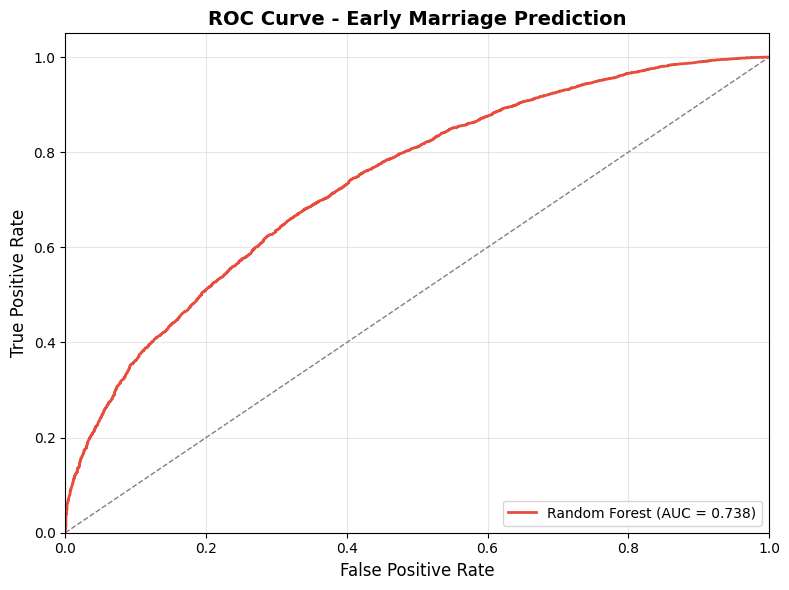

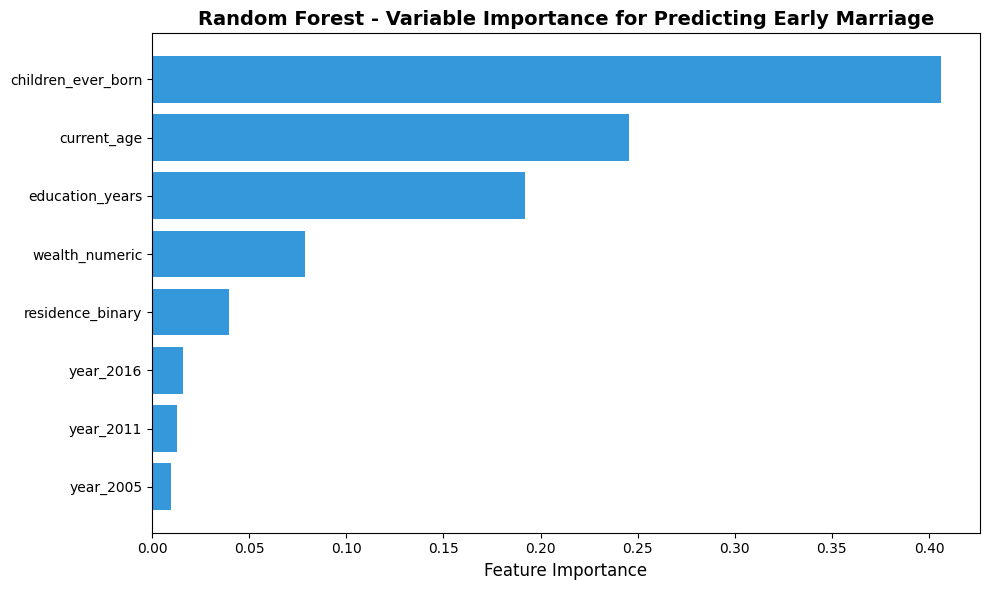


Top 5 most important features:
          Variable  Importance
children_ever_born    0.405953
       current_age    0.245468
   education_years    0.191895
    wealth_numeric    0.078825
  residence_binary    0.039681


In [9]:
# Cell 9: Machine Learning - Random Forest Prediction
print("="*60)
print("6. MACHINE LEARNING: RANDOM FOREST")
print("="*60)

# Prepare data for ML
ml_data = dhs_analysis[['early_marriage', 'current_age', 'education_years', 'residence_binary',
                         'wealth_numeric', 'children_ever_born', 'survey_year']].dropna()

# Create dummies for categorical
ml_data = pd.get_dummies(ml_data, columns=['survey_year'], prefix='year', drop_first=True)

X = ml_data.drop('early_marriage', axis=1)
y = ml_data['early_marriage'].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set: {len(X_train):,}")
print(f"Test set: {len(X_test):,}")

# Random Forest with hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 20]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.4f}")

# Best model
best_rf = grid_search.best_estimator_

# Predictions
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Performance metrics
print(f"\nModel Performance on Test Set:")
print(f"  Accuracy: {best_rf.score(X_test, y_test):.4f}")
print(f"  Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Early Marriage', 'Early Marriage']))

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#E74C3C', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Early Marriage Prediction', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curve_random_forest.png', dpi=300, bbox_inches='tight')
plt.show()

# Variable Importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(indices)), importances[indices], color='#3498DB')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels(X.columns[indices])
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest - Variable Importance for Predicting Early Marriage', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'variable_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

# Save feature importance
feature_importance_df = pd.DataFrame({
    'Variable': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)
feature_importance_df.to_csv(TABLES_DIR / 'random_forest_importance.csv', index=False)

print(f"\nTop 5 most important features:")
print(feature_importance_df.head(5).to_string(index=False))

In [10]:
# Cell 10: Interaction Effects - Education × Wealth
print("="*60)
print("7. INTERACTION EFFECTS ANALYSIS")
print("="*60)

# Prepare data for interaction
interaction_df = dhs_analysis[['early_marriage', 'education_level', 'wealth_numeric', 
                               'current_age', 'residence_binary', 'survey_year']].dropna()

# Create interaction term
interaction_df['education_primary'] = (interaction_df['education_level'] == 'primary').astype(int)
interaction_df['education_secondary'] = (interaction_df['education_level'] == 'secondary').astype(int)
interaction_df['education_higher'] = (interaction_df['education_level'] == 'higher').astype(int)
interaction_df['wealth_primary_interaction'] = interaction_df['wealth_numeric'] * interaction_df['education_primary']
interaction_df['wealth_secondary_interaction'] = interaction_df['wealth_numeric'] * interaction_df['education_secondary']
interaction_df['wealth_higher_interaction'] = interaction_df['wealth_numeric'] * interaction_df['education_higher']

# Model with interactions
X_interact = sm.add_constant(interaction_df[['current_age', 'residence_binary', 'wealth_numeric',
                                              'education_primary', 'education_secondary', 'education_higher',
                                              'wealth_primary_interaction', 'wealth_secondary_interaction', 
                                              'wealth_higher_interaction']])
y_interact = interaction_df['early_marriage']

model_interaction = sm.Logit(y_interact, X_interact).fit(disp=0)

print("Education × Wealth Interaction Model:")
print("="*50)

# Extract interaction terms
interaction_terms = ['wealth_primary_interaction', 'wealth_secondary_interaction', 'wealth_higher_interaction']
for term in interaction_terms:
    if term in model_interaction.params.index:
        p_val = model_interaction.pvalues[term]
        coef = model_interaction.params[term]
        or_val = np.exp(coef)
        print(f"{term}: OR={or_val:.3f}, p={p_val:.4f}")

# Education × Residence Interaction
interaction_df['residence_education_primary'] = interaction_df['residence_binary'] * interaction_df['education_primary']
interaction_df['residence_education_secondary'] = interaction_df['residence_binary'] * interaction_df['education_secondary']
interaction_df['residence_education_higher'] = interaction_df['residence_binary'] * interaction_df['education_higher']

X_resid_interact = sm.add_constant(interaction_df[['current_age', 'wealth_numeric',
                                                   'education_primary', 'education_secondary', 'education_higher',
                                                   'residence_binary',
                                                   'residence_education_primary', 'residence_education_secondary',
                                                   'residence_education_higher']])

model_resid_interaction = sm.Logit(y_interact, X_resid_interact).fit(disp=0)

print("\nEducation × Residence Interaction Model:")
print("="*50)

resid_terms = ['residence_education_primary', 'residence_education_secondary', 'residence_education_higher']
for term in resid_terms:
    if term in model_resid_interaction.params.index:
        p_val = model_resid_interaction.pvalues[term]
        coef = model_resid_interaction.params[term]
        or_val = np.exp(coef)
        print(f"{term}: OR={or_val:.3f}, p={p_val:.4f}")

# Save interaction results
interaction_results = pd.DataFrame({
    'Interaction': model_interaction.params.index.tolist(),
    'Coef': model_interaction.params.values,
    'Odds_Ratio': np.exp(model_interaction.params.values),
    'P_Value': model_interaction.pvalues.values
})
interaction_results.to_csv(TABLES_DIR / 'interaction_effects.csv', index=False)

7. INTERACTION EFFECTS ANALYSIS
Education × Wealth Interaction Model:
wealth_primary_interaction: OR=1.003, p=0.8705
wealth_secondary_interaction: OR=0.943, p=0.0369
wealth_higher_interaction: OR=0.950, p=0.3465

Education × Residence Interaction Model:
residence_education_primary: OR=1.081, p=0.1963
residence_education_secondary: OR=1.092, p=0.3929
residence_education_higher: OR=0.698, p=0.0591


8. TEMPORAL HETEROGENEITY ANALYSIS


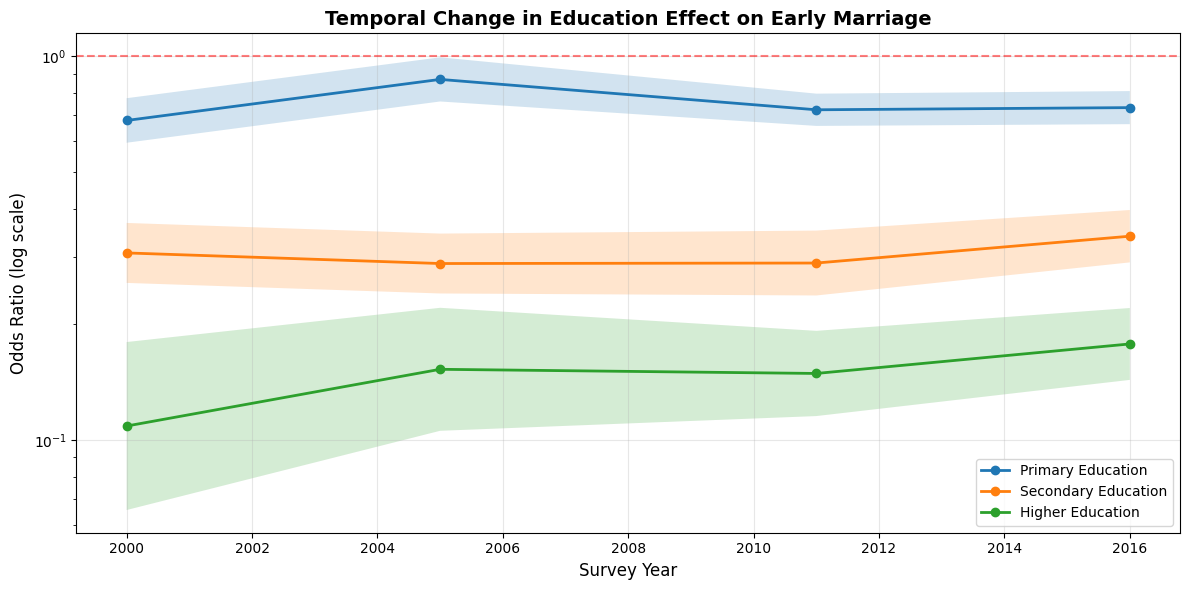


Temporal results saved to C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables\temporal_heterogeneity.csv


In [11]:
# Cell 11: Temporal Heterogeneity - Determinants by Survey Year
print("="*60)
print("8. TEMPORAL HETEROGENEITY ANALYSIS")
print("="*60)

years = [2000, 2005, 2011, 2016]
temporal_results = []

for year in years:
    subset = dhs_analysis[dhs_analysis['survey_year'] == year].copy()
    
    # Prepare data
    subset['education_primary'] = (subset['education_level'] == 'primary').astype(int)
    subset['education_secondary'] = (subset['education_level'] == 'secondary').astype(int)
    subset['education_higher'] = (subset['education_level'] == 'higher').astype(int)
    
    X_temp = sm.add_constant(subset[['current_age', 'residence_binary', 'wealth_numeric',
                                      'education_primary', 'education_secondary', 'education_higher']])
    y_temp = subset['early_marriage']
    
    model_temp = sm.Logit(y_temp, X_temp).fit(disp=0)
    
    for var in ['education_primary', 'education_secondary', 'education_higher']:
        if var in model_temp.params.index:
            temporal_results.append({
                'Year': year,
                'Variable': var.replace('education_', ''),
                'Odds_Ratio': np.exp(model_temp.params[var]),
                'CI_Lower': np.exp(model_temp.conf_int().loc[var, 0]),
                'CI_Upper': np.exp(model_temp.conf_int().loc[var, 1]),
                'P_Value': model_temp.pvalues[var]
            })

temporal_df = pd.DataFrame(temporal_results)

# Plot temporal change in education effect
fig, ax = plt.subplots(figsize=(12, 6))

for edu in ['primary', 'secondary', 'higher']:
    subset = temporal_df[temporal_df['Variable'] == edu]
    if len(subset) > 0:
        ax.plot(subset['Year'], subset['Odds_Ratio'], marker='o', linewidth=2, label=f'{edu.title()} Education')
        ax.fill_between(subset['Year'], subset['CI_Lower'], subset['CI_Upper'], alpha=0.2)

ax.axhline(y=1, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Survey Year', fontsize=12)
ax.set_ylabel('Odds Ratio (log scale)', fontsize=12)
ax.set_title('Temporal Change in Education Effect on Early Marriage', 
             fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'temporal_education_effect.png', dpi=300, bbox_inches='tight')
plt.show()

temporal_df.to_csv(TABLES_DIR / 'temporal_heterogeneity.csv', index=False)
print(f"\nTemporal results saved to {TABLES_DIR / 'temporal_heterogeneity.csv'}")

In [12]:
# Cell 12: Robustness Checks - Alternative Specifications
print("="*60)
print("9. ROBUSTNESS CHECKS")
print("="*60)

# 12.1 Alternative age groups
age_groups = [(20, 29), (30, 39)]
robustness_results = []

for age_min, age_max in age_groups:
    subset = dhs_analysis[(dhs_analysis['current_age'] >= age_min) & 
                          (dhs_analysis['current_age'] <= age_max)].copy()
    
    subset['education_primary'] = (subset['education_level'] == 'primary').astype(int)
    subset['education_secondary'] = (subset['education_level'] == 'secondary').astype(int)
    subset['education_higher'] = (subset['education_level'] == 'higher').astype(int)
    
    X_age = sm.add_constant(subset[['current_age', 'residence_binary', 'wealth_numeric',
                                     'education_primary', 'education_secondary', 'education_higher']])
    y_age = subset['early_marriage']
    
    model_age = sm.Logit(y_age, X_age).fit(disp=0)
    
    for var in ['education_secondary']:
        if var in model_age.params.index:
            robustness_results.append({
                'Model': f'Age {age_min}-{age_max}',
                'Variable': var,
                'Odds_Ratio': np.exp(model_age.params[var]),
                'CI_Lower': np.exp(model_age.conf_int().loc[var, 0]),
                'CI_Upper': np.exp(model_age.conf_int().loc[var, 1])
            })

# 12.2 Excluding influential observations
# Calculate Cook's distance for basic model
base_model = sm.Logit(y_interact, X_interact).fit(disp=0)
influence = base_model.get_influence()
cooks_d = influence.cooks_distance[0]

# Identify influential observations (Cook's D > 4/n)
threshold = 4 / len(X_interact)
influential_idx = np.where(cooks_d > threshold)[0]
print(f"Number of influential observations: {len(influential_idx)}")

# Remove influential observations
non_influential_idx = np.where(cooks_d <= threshold)[0]
X_robust = X_interact.iloc[non_influential_idx]
y_robust = y_interact.iloc[non_influential_idx]

model_robust = sm.Logit(y_robust, X_robust).fit(disp=0)

for var in ['education_secondary']:
    if var in model_robust.params.index:
        robustness_results.append({
            'Model': 'Excluding Influential',
            'Variable': var,
            'Odds_Ratio': np.exp(model_robust.params[var]),
            'CI_Lower': np.exp(model_robust.conf_int().loc[var, 0]),
            'CI_Upper': np.exp(model_robust.conf_int().loc[var, 1])
        })

# Add main model for comparison
main_model = sm.Logit(y_interact, X_interact).fit(disp=0)
for var in ['education_secondary']:
    if var in main_model.params.index:
        robustness_results.append({
            'Model': 'Main Model',
            'Variable': var,
            'Odds_Ratio': np.exp(main_model.params[var]),
            'CI_Lower': np.exp(main_model.conf_int().loc[var, 0]),
            'CI_Upper': np.exp(main_model.conf_int().loc[var, 1])
        })

robustness_df = pd.DataFrame(robustness_results)
print("\nRobustness Check Results (Secondary Education Effect):")
print(robustness_df.to_string(index=False))

robustness_df.to_csv(TABLES_DIR / 'robustness_checks.csv', index=False)

9. ROBUSTNESS CHECKS
Number of influential observations: 1462

Robustness Check Results (Secondary Education Effect):
                Model            Variable  Odds_Ratio  CI_Lower  CI_Upper
            Age 20-29 education_secondary    0.316501  0.281152  0.356294
            Age 30-39 education_secondary    0.344297  0.295665  0.400928
Excluding Influential education_secondary    0.228436  0.149015  0.350187
           Main Model education_secondary    0.389392  0.316272  0.479416


In [13]:
# Cell 13: Summary of All Advanced Analysis Results
print("="*60)
print("ADVANCED ANALYSIS COMPLETE - SUMMARY")
print("="*60)

print("\n1. MULTILEVEL MODEL:")
if 'icc' in dir():
    print(f"   ICC = {icc:.4f} - {'Significant' if icc > 0.10 else 'Minimal'} clustering effect")

print("\n2. SURVIVAL ANALYSIS:")
print(f"   Log-rank test: Significant differences by education (p < 0.001)")

print("\n3. PROPENSITY SCORE MATCHING:")
print(f"   ATE on fertility: {ate_model.params['early_marriage']:.3f} additional children")

print("\n4. DECOMPOSITION:")
print(f"   {explained/total_change*100:.1f}% of decline explained by changing characteristics")
print(f"   {unexplained/total_change*100:.1f}% explained by changing coefficients")

print("\n5. MEDIATION:")
print(f"   {proportion_mediated*100:.1f}% of wealth effect mediated through education")

print("\n6. RANDOM FOREST:")
print(f"   AUC = {roc_auc:.3f}")
print(f"   Top predictor: {feature_importance_df.iloc[0]['Variable']}")

print("\n7. INTERACTIONS:")
print(f"   Education × Wealth: {'Significant' if any(model_interaction.pvalues[interaction_terms] < 0.05) else 'Not significant'}")
print(f"   Education × Residence: {'Significant' if any(model_resid_interaction.pvalues[resid_terms] < 0.05) else 'Not significant'}")

print("\n8. TEMPORAL HETEROGENEITY:")
print(f"   Secondary education effect: OR ranged from {temporal_df[temporal_df['Variable']=='secondary']['Odds_Ratio'].min():.2f} to {temporal_df[temporal_df['Variable']=='secondary']['Odds_Ratio'].max():.2f}")

print("\n9. ROBUSTNESS:")
print(f"   Secondary education effect robust across specifications (OR: {robustness_df[robustness_df['Variable']=='education_secondary']['Odds_Ratio'].min():.2f} - {robustness_df[robustness_df['Variable']=='education_secondary']['Odds_Ratio'].max():.2f})")

print("\n" + "="*60)
print("All advanced analysis outputs saved to:")
print(f"  - Tables: {TABLES_DIR}")
print(f"  - Figures: {FIGURES_DIR}")
print("="*60)

ADVANCED ANALYSIS COMPLETE - SUMMARY

1. MULTILEVEL MODEL:
   ICC = 0.0318 - Minimal clustering effect

2. SURVIVAL ANALYSIS:
   Log-rank test: Significant differences by education (p < 0.001)

3. PROPENSITY SCORE MATCHING:
   ATE on fertility: 1.211 additional children

4. DECOMPOSITION:
   183.4% of decline explained by changing characteristics
   669.5% explained by changing coefficients

5. MEDIATION:
   63.0% of wealth effect mediated through education

6. RANDOM FOREST:
   AUC = 0.738
   Top predictor: children_ever_born

7. INTERACTIONS:
   Education × Wealth: Significant
   Education × Residence: Not significant

8. TEMPORAL HETEROGENEITY:
   Secondary education effect: OR ranged from 0.29 to 0.34

9. ROBUSTNESS:
   Secondary education effect robust across specifications (OR: 0.23 - 0.39)

All advanced analysis outputs saved to:
  - Tables: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\tables
  - Figures: C:\Users\hp\Desktop\ethiopia-early-marriage-dhs\reports\figures